# Bathymetry Processing Notebook
This notebook processes depth measurements to generate a bathymetric map clipped to a lake boundary and saves the result as a GeoJSON file.

## Import Required Libraries
We import necessary libraries for data manipulation, interpolation, geospatial operations, and visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import pandas as pd
from shapely.geometry import Point, mapping
import json
import geopandas as gpd

## Load Depth Data
We load depth measurements from a CSV file containing longitude, latitude, and depth values.

In [2]:
df = pd.read_csv("Maschsee_depth_complete.csv")  # Replace with your file
points = df[['longitude', 'latitude']].values
depths = df['depth'].values

## Interpolate Depth Values
We interpolate the depth values onto a regular grid using cubic interpolation.

In [3]:
x = points[:, 0]
y = points[:, 1]
depth = depths

grid_x, grid_y = np.meshgrid(np.linspace(min(x), max(x), 100),
                             np.linspace(min(y), max(y), 100))

grid_depth = griddata((x, y), depth, (grid_x, grid_y), method='cubic')

## Scale Depth Values
We normalize and scale the interpolated depth values to have an average of 2.0 and a maximum of 2.5.

In [4]:
valid_mask = ~np.isnan(grid_depth)
original = grid_depth[valid_mask]
scaled = (original - np.min(original)) / (np.max(original) - np.min(original))  # Normalize to [0, 1]
scaled = scaled * (2.5 - 1.5) + 1.5  # Scale to [1.5, 2.5]
scale_factor = 2.0 / np.mean(scaled)  # Adjust to get average 2.0
scaled *= scale_factor
scaled = np.clip(scaled, 0, 2.5)

grid_depth[valid_mask] = scaled

## Clip to Lake Boundary
We clip the interpolated depth values to the lake boundary using a GeoJSON file.

In [5]:
lake_boundary = gpd.read_file("/content/maschsee_bounadries.geojson").geometry.iloc[0]

features = []
for i in range(grid_x.shape[0]):
    for j in range(grid_x.shape[1]):
        pt = Point(grid_x[i, j], grid_y[i, j])
        if lake_boundary.contains(pt) and not np.isnan(grid_depth[i, j]):
            feature = {
                "type": "Feature",
                "geometry": mapping(pt),
                "properties": {"depth": float(grid_depth[i, j])}
            }
            features.append(feature)
        else:
            grid_depth[i, j] = 0

## Create and Save GeoJSON
We create a GeoJSON structure from the clipped depth values and save it to a file.

In [6]:
geojson_data = {
    "type": "FeatureCollection",
    "features": features
}

with open("bathymetry_map_maschsee150825geojson", "w") as f:
    json.dump(geojson_data, f)

print("Bathymetry saved to 'bathymetry_map_maschsee.geojson'.")

Bathymetry saved to 'bathymetry_map_maschsee.geojson'.


## Visualize Bathymetric Map
We plot the bathymetric map using matplotlib.

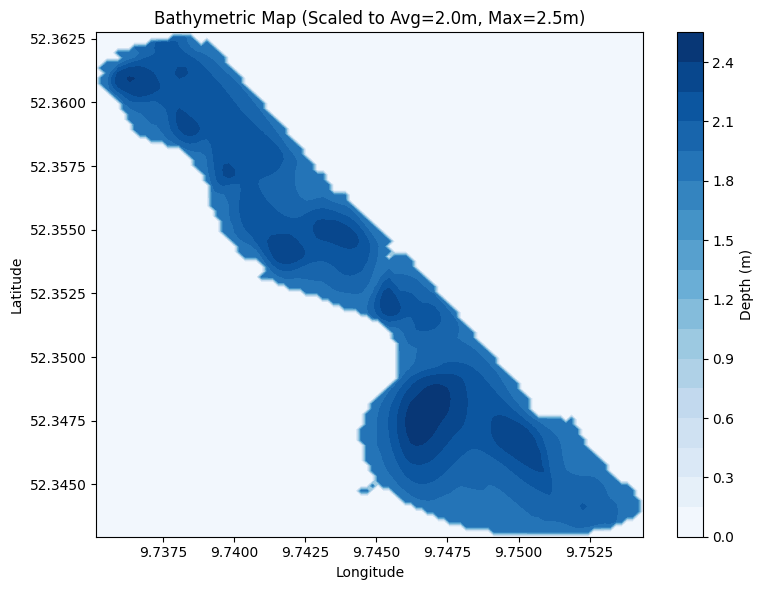

In [7]:
plt.figure(figsize=(8, 6))
contour = plt.contourf(grid_x, grid_y, grid_depth, levels=20, cmap='Blues')
plt.colorbar(contour, label='Depth (m)')
plt.title('Bathymetric Map (Scaled to Avg=2.0m, Max=2.5m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()